In [1]:
import numpy as np
import hockey.hockey_env as h_env
import gymnasium as gym
from importlib import reload
import time

In [2]:
np.set_printoptions(suppress=True)

In [3]:
# reload(h_env)

# Normal Game Play

In [4]:
env = h_env.HockeyEnv()

have a look at the initialization condition: alternating who starts and are random in puck position

In [5]:
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()
_ = env.render()

one episode with random agents

In [6]:
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()

for _ in range(600):
    env.render(mode="human")
    a1 = np.random.uniform(-1,1,4)
    a2 = np.random.uniform(-1,1,4)    
    obs, r, d, t, info = env.step(np.hstack([a1,a2]))    
    obs_agent2 = env.obs_agent_two()
    if d or t: break

Without rendering, it runs much faster

"info" dict contains useful proxy rewards and winning information

In [7]:
info, env.get_info_agent_two()

({'winner': 1,
  'reward_closeness_to_puck': 0.0,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': 0.0038207104492187505},
 {'winner': -1,
  'reward_closeness_to_puck': -0.15272891694160545,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': -0.0038207104492187505})

Winner == 0: draw

Winner == 1: you (left player)

Winner == -1: opponent wins (right player)

In [8]:
env.close()

# Train Shooting

In [9]:
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_SHOOTING)

In [10]:
o, info = env.reset()
_ = env.render()

for _ in range(50):
    env.render()
    a1 = [1,0,0,1] # np.random.uniform(-1,1,4)
    a2 = [0,0.,0,0] 
    obs, r, d, t , info = env.step(np.hstack([a1,a2]))
    obs_agent2 = env.obs_agent_two()
    if d or t: break

In [11]:
env.close()

# Train DEFENDING

In [12]:
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_DEFENSE)

In [13]:
o, info = env.reset()
_ = env.render()

for _ in range(60):
    env.render()
    a1 = [0.1,0,0,1] # np.random.uniform(-1,1,3)
    a2 = [0,0.,0,0] 
    obs, r, d, t, info = env.step(np.hstack([a1,a2]))
    obs_agent2 = env.obs_agent_two()
    if d or t: break

In [14]:
env.close()

# Using discrete actions

In [15]:
import random

In [16]:
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_SHOOTING)

In [17]:
env.reset()
for _ in range(251):
    env.render()
    a1_discrete = random.randint(0,7)
    a1 = env.discrete_to_continous_action(a1_discrete)
    a2 = [0,0.,0,0 ] 
    obs, r, d, t, info = env.step(np.hstack([a1,a2]))    
    obs_agent2 = env.obs_agent_two()
    if d or t: break

In [18]:
env.close()

# Hand-crafted Opponent

In [19]:
env = h_env.HockeyEnv()

In [20]:
o, info = env.reset()
_ = env.render()
player1 = h_env.BasicOpponent(weak=False)
player2 = h_env.BasicOpponent()

In [21]:
obs_buffer = []
reward_buffer=[]
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()
for _ in range(251):
    env.render()
    a1 = player1.act(obs)
    a2 = player2.act(obs_agent2)
    obs, r, d, t, info = env.step(np.hstack([a1,a2]))    
    obs_buffer.append(obs)
    reward_buffer.append(r)
    obs_agent2 = env.obs_agent_two()
    if d or t: break
obs_buffer = np.asarray(obs_buffer)
reward_buffer = np.asarray(reward_buffer)

In [22]:
np.mean(obs_buffer,axis=0)

array([-1.95201449,  0.12000107, -0.50746756, -0.39960347,  0.08684092,
       -0.70619617,  1.49820905, -0.01975264, -0.0545668 , -0.35135492,
       -0.53777354, -0.34602921,  0.41711344, -0.61461308,  7.78187513,
       -0.45827216,  2.76315789,  0.        ])

In [23]:
np.std(obs_buffer,axis=0)

array([ 0.75155992,  0.1135296 ,  0.37166659,  6.52837091,  1.19356455,
        2.28082075,  0.82225385,  0.13111969,  0.11499104,  7.16993099,
        0.94753112,  0.53167413,  1.82956025,  1.13813495,  9.96547774,
       13.43128894,  4.8527486 ,  0.        ])

If you want to use a fixed observation scaling, this might be a reasonable choice

In [24]:
scaling = [ 1.0,  1.0 , 0.5, 4.0, 4.0, 4.0,  
            1.0,  1.0,  0.5, 4.0, 4.0, 4.0,  
            2.0, 2.0, 10.0, 10.0, 4,0 ,4,0]

In [25]:
import pylab as plt

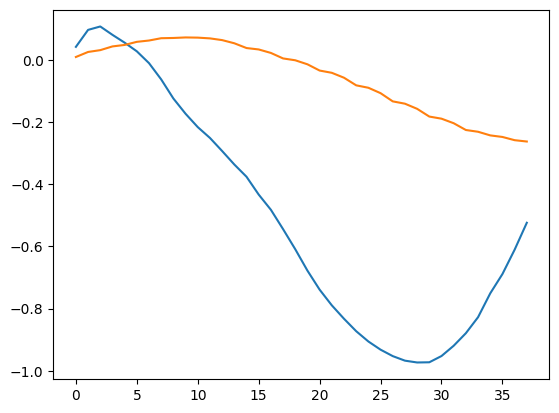

In [26]:
plt.plot(obs_buffer[:,2])
plt.plot(obs_buffer[:,8])

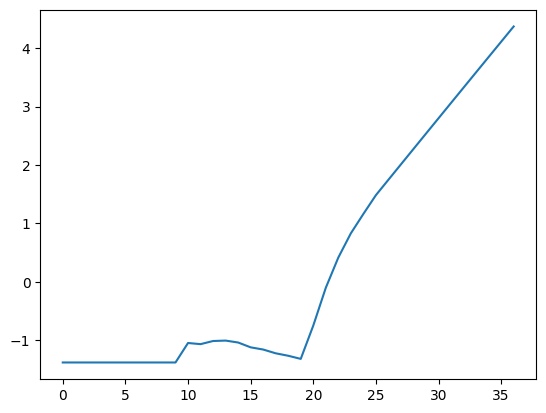

In [42]:
plt.plot(obs_buffer[:,12])

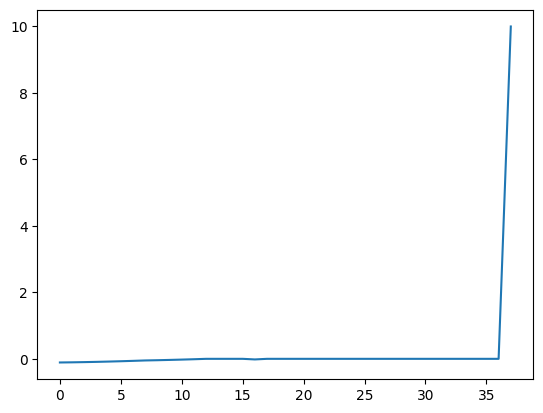

In [27]:
plt.plot(reward_buffer[:])

In [28]:
np.sum(reward_buffer)

9.202298181686835

In [29]:
info2 = env.get_info_agent_two()
info, info2, env.get_reward(info), env.get_reward_agent_two(info2)

({'winner': 1,
  'reward_closeness_to_puck': 0.0,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': 0.0017614627075195313},
 {'winner': -1,
  'reward_closeness_to_puck': -0.08103424424204378,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': -0.0017614627075195313},
 10.0,
 -10.081034244242044)

In [30]:
env.close()

# Human Opponent

In [31]:
env = h_env.HockeyEnv()

In [32]:
player1 = h_env.HumanOpponent(env=env, player=1)
player2 = h_env.BasicOpponent()


Human Controls:
 left:			left arrow key left
 right:			arrow key right
 up:			arrow key up
 down:			arrow key down
 tilt clockwise:	w
 tilt anti-clockwise:	s
 shoot :	space


In [33]:
player1 = h_env.BasicOpponent()
player2 = h_env.HumanOpponent(env=env, player=2)


Human Controls:
 left:			left arrow key left
 right:			arrow key right
 up:			arrow key up
 down:			arrow key down
 tilt clockwise:	w
 tilt anti-clockwise:	s
 shoot :	space


In [34]:
obs, info = env.reset()

env.render()
time.sleep(1)
obs_agent2 = env.obs_agent_two()
for _ in range(100):
    time.sleep(0.2)
    env.render()
    a1 = player1.act(obs) 
    a2 = player2.act(obs_agent2)
    obs, r, d, _, info = env.step(np.hstack([a1,a2]))    
    obs_agent2 = env.obs_agent_two()
    if d: break

In [35]:
env.close()

# Check side consistency

In [36]:
env = h_env.HockeyEnv()

In [37]:
o, info = env.reset()
_ = env.render()
player1 = h_env.BasicOpponent(weak=False)
player2 = h_env.BasicOpponent(weak=False)

In [38]:
obs_buffer = []
reward_buffer=[]
obs2_buffer = []
winner_buffer = []
reward2_buffer=[]
for game in range(1000):
    obs, info = env.reset()
    obs_agent2 = env.obs_agent_two()
    for _ in range(500):
        # env.render()
        a1 = player1.act(obs)
        a2 = player2.act(obs_agent2)
#        a1 = np.random.uniform(-1,1,4)
#        a2 = np.random.uniform(-1,1,4)    
        obs, r, d, t, info = env.step(np.hstack([a1,a2]))
        info2 = env.get_info_agent_two()
        r2 = env.get_reward_agent_two(info2)
        obs_buffer.append(obs)
        obs_agent2 = env.obs_agent_two()
        obs2_buffer.append(obs_agent2)
        reward_buffer.append(r)
        reward2_buffer.append(r2)
        if d or t:
            winner_buffer.append(info["winner"])
            break
obs_buffer = np.asarray(obs_buffer)
reward_buffer = np.asarray(reward_buffer)
obs2_buffer = np.asarray(obs2_buffer)
reward2_buffer = np.asarray(reward2_buffer)

In [39]:
obs_buffer.shape

(157081, 18)

In [40]:
np.mean(obs_buffer,axis=0)

array([-2.97985888, -0.00369919,  0.00205171, -0.05839302, -0.00846156,
       -0.0108938 ,  2.97543939,  0.00168738,  0.0004537 ,  0.05753994,
       -0.01039066,  0.00181833,  0.00241172, -0.0079224 , -0.0497282 ,
       -0.01300605,  1.09424437,  1.11763994])

In [41]:
(np.std(obs_buffer,axis=0) - np.std(obs2_buffer,axis=0)) / np.std(obs_buffer,axis=0)

array([-0.00612297,  0.00253317, -0.00179494, -0.00110133,  0.01095902,
        0.00080622,  0.00608571, -0.0025396 ,  0.00179173,  0.00110011,
       -0.01108045, -0.00080687,  0.        ,  0.        ,  0.        ,
        0.        , -0.00947308,  0.00938418])

In [42]:
winner_buffer

[-1,
 -1,
 0,
 0,
 0,
 1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 -1,
 0,
 0,
 0,
 -1,
 0,
 0,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 0,
 -1,
 0,
 -1,
 1,
 1,
 1,
 -1,
 1,
 0,
 0,
 0,
 -1,
 0,
 0,
 -1,
 1,
 0,
 -1,
 -1,
 1,
 -1,
 0,
 0,
 0,
 -1,
 1,
 0,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 0,
 0,
 1,
 -1,
 1,
 -1,
 0,
 0,
 0,
 0,
 -1,
 -1,
 1,
 -1,
 0,
 -1,
 -1,
 0,
 1,
 1,
 0,
 -1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 -1,
 0,
 -1,
 1,
 0,
 0,
 0,
 -1,
 -1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 0,
 0,
 -1,
 0,
 1,
 1,
 0,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 0,
 1,
 -1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 -1,
 0,
 0,
 0,
 -1,
 -1,
 0,
 1,
 0,
 0,
 -1,
 1,
 -1,
 1,
 0,
 0,
 -1,
 1,
 1,
 0,
 0,
 0,
 0,
 -1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 -1,
 0,
 1,
 -1,
 0,
 0,
 -1,
 -1,
 -1,
 1,
 0,
 -1,
 0,
 1,
 -1,
 0,
 1,
 -1,
 0,
 -1,
 -1,
 0,
 0,
 -1,
 -1,
 -1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 -1,
 1,
 -1,
 0,
 -1,
 1,
 -1,
 1,
 1,
 1,
 0,
 -1,
 1,
 0,
 -1,


In [43]:
np.mean(winner_buffer,axis=0)

-0.034

In [44]:
np.std(winner_buffer,axis=0)

0.7879365456684948

In [45]:
np.sum(reward_buffer), np.sum(reward2_buffer)

(-4942.1506170335515, -4043.6686483948392)

In [46]:
env.close()

# Test Trained Rainbow Agent

In [47]:
# Load Rainbow agent
import json
import torch
import copy
from agents.rainbow import RainbowAgent

# Path to the trained Rainbow model 
rainbow_model_path = "logs/Rainbow_no_noisy_20260222_011934/checkpoint_250000.pt"
rainbow_model2_path = "logs/Rainbow_no_noisy_20260222_011934/best_model.pt"

rainbow_config_path = "logs/Rainbow_no_noisy_20260222_011934/config.json"

# Load config
with open(rainbow_config_path, 'r') as f:
    saved_config = json.load(f)

# Load checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(rainbow_model_path, map_location=device, weights_only=False)
checkpoint2 = torch.load(rainbow_model2_path, map_location=device, weights_only=False)
model_config = checkpoint['config']

print(f"Model config: {model_config}")

# Create Rainbow agent with exact dimensions from checkpoint
rainbow_agent = RainbowAgent(
    state_dim=model_config['state_dim'],
    action_dim=model_config['action_dim'],
    hidden_dims=tuple(saved_config['hidden_dims']),
    lr=saved_config['lr'],
    gamma=model_config['gamma'],
    buffer_size=saved_config['buffer_size'],
    batch_size=saved_config['batch_size'],
    n_step=model_config['n_step'],
    num_atoms=model_config['num_atoms'],
    v_min=model_config['v_min'],
    v_max=model_config['v_max'],
    alpha=saved_config['alpha'],
    beta_start=saved_config['beta_start'],
    noisy=model_config['noisy'],
    device="auto"
)
rainbow_agent2 = copy.deepcopy(rainbow_agent)  # Create a second agent with the same architecture and hyperparameters

# Load the trained weights
rainbow_agent.online_network.load_state_dict(checkpoint['online_network_state_dict'])
rainbow_agent.target_network.load_state_dict(checkpoint['target_network_state_dict'])
rainbow_agent2.online_network.load_state_dict(checkpoint2['online_network_state_dict'])
rainbow_agent2.target_network.load_state_dict(checkpoint2['target_network_state_dict'])
print(f" Rainbow agent loaded from: {rainbow_model_path}")
print(f"  Training steps: {checkpoint.get('step_count', 'N/A'):,}")

Model config: {'state_dim': 18, 'action_dim': 8, 'gamma': 0.99, 'n_step': 3, 'num_atoms': 51, 'v_min': -10.0, 'v_max': 10.0, 'noisy': False}
 Rainbow agent loaded from: logs/Rainbow_no_noisy_20260222_011934/checkpoint_250000.pt
  Training steps: 13,776,545


In [48]:
# Test Rainbow agent as Player 1 
env = h_env.HockeyEnv()

player1 = rainbow_agent  # trained agent - Player 1 (left, red)
player2 = h_env.BasicOpponent(weak=True)  # Opponent - Player 2 (right, blue)

winners = []
rewards = []
num_episodes = 20

print(f"Testing Rainbow agent as Player 1 against weak BasicOpponent...")
print(f"Running {num_episodes} episodes...")

for episode in range(num_episodes):
    obs, info = env.reset()
    obs_agent2 = env.obs_agent_two()
    episode_reward = 0
    
    for step in range(251):
        a1 = env.discrete_to_continous_action(player1.select_action(obs, training=False))
        a2 = player2.act(obs_agent2)
        
        obs, r, d, t, info = env.step(np.hstack([a1, a2]))
        obs_agent2 = env.obs_agent_two()
        episode_reward += r
        
        if d or t:
            break
    
    winners.append(info['winner'])
    rewards.append(episode_reward)

env.close()

# Results
wins = sum(1 for w in winners if w == 1)
losses = sum(1 for w in winners if w == -1)
draws = sum(1 for w in winners if w == 0)

print(f"Results over {num_episodes} episodes:")
print(f"  Wins:   {wins} ({wins/num_episodes*100:.1f}%)")
print(f"  Losses: {losses} ({losses/num_episodes*100:.1f}%)")
print(f"  Draws:  {draws} ({draws/num_episodes*100:.1f}%)")
print(f"  Avg Reward: {np.mean(rewards):.2f}")


Testing Rainbow agent as Player 1 against weak BasicOpponent...
Running 20 episodes...
Results over 20 episodes:
  Wins:   19 (95.0%)
  Losses: 1 (5.0%)
  Draws:  0 (0.0%)
  Avg Reward: 8.60


In [49]:
# Visual test 
env = h_env.HockeyEnv()

player1 = rainbow_agent  # one agent as Player 1
player2 = rainbow_agent2 #h_env.BasicOpponent(weak=False) # one agent as Player 2

obs, info = env.reset()
obs_agent2 = env.obs_agent_two()
_ = env.render()
num_episodes = 20
print("Watching Rainbow agents play...")

winners = []
for episode in range(num_episodes):
    obs, info = env.reset()
    obs_agent2 = env.obs_agent_two()
    _ = env.render()
    for step in range(251):
        env.render(mode="human")
        
        a1 = env.discrete_to_continous_action(player1.select_action(obs, training=False))
        a2 = env.discrete_to_continous_action(player2.select_action(obs_agent2, training=False)) #player2.act(obs_agent2)
        
        obs, r, d, t, info = env.step(np.hstack([a1, a2]))
        obs_agent2 = env.obs_agent_two()
        
        if d or t:
            winners.append(info['winner'])
            break

print(f"Game ended - Winner: {info['winner']}")
env.close()

Watching Rainbow agents play...
Game ended - Winner: 1


In [51]:
winners.count(1), winners.count(-1), winners.count(0)

(10, 10, 0)